# Breast Cancer Classification Using Logistic Regression

**Author:** Aqib Niazi  
**Dataset:** Wisconsin Breast Cancer Dataset (UCI Machine Learning Repository)  
**Objective:** Build a binary classification model to predict whether a breast tumor is Malignant or Benign based on 30 numerical features extracted from Fine Needle Aspiration (FNA) biopsy images.

---

## Table of Contents

1. [Problem Statement](#1-problem-statement)
2. [Dataset Overview](#2-dataset-overview)
3. [Import Libraries](#3-import-libraries)
4. [Load and Inspect Data](#4-load-and-inspect-data)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Data Preprocessing](#6-data-preprocessing)
7. [Feature Scaling](#7-feature-scaling)
8. [Model Training](#8-model-training)
9. [Model Evaluation](#9-model-evaluation)
10. [Feature Importance Analysis](#10-feature-importance-analysis)
11. [Model Export](#11-model-export)
12. [Conclusions](#12-conclusions)

## 1. Problem Statement

Breast cancer is one of the most common cancers worldwide and is the second leading cause of cancer-related deaths among women. Early and accurate diagnosis is critical — the five-year survival rate for localized breast cancer is over 99%, but drops significantly when the disease has spread.

Traditional diagnosis requires trained pathologists to examine biopsy samples under a microscope. Machine learning offers a complementary approach: by learning patterns from digitized biopsy measurements, a model can assist clinicians in making faster and more consistent diagnostic decisions.

**This notebook addresses the following question:**

> Given 30 numerical measurements extracted from a Fine Needle Aspiration biopsy image, can we reliably predict whether a tumor is Malignant (cancerous) or Benign (non-cancerous)?

**Why Logistic Regression?**

Logistic Regression is an interpretable, well-established algorithm for binary classification. In clinical settings, model interpretability is not a luxury — it is a requirement. A physician needs to understand why a model made a prediction, not just what the prediction is. Logistic Regression provides coefficient-level interpretability that more complex models like neural networks cannot easily offer.

## 2. Dataset Overview

The **Wisconsin Breast Cancer Dataset** was created by Dr. William H. Wolberg at the University of Wisconsin. Features are computed from digitized images of fine needle aspirates of breast masses and describe characteristics of the cell nuclei present in the image.

**Key facts:**

| Property | Value |
|---|---|
| Total samples | 569 |
| Malignant (M) | 212 (37.3%) |
| Benign (B) | 357 (62.7%) |
| Features | 30 numerical |
| Missing values | None |
| Source | UCI ML Repository / Kaggle |

**Feature structure:**

Ten base measurements are captured for each cell nucleus. Each measurement is then represented in three forms, giving 30 features total:

| Form | Description |
|---|---|
| Mean | Average value across all nuclei in the sample |
| Standard Error (SE) | Statistical spread / uncertainty of the measurement |
| Worst | The largest (most extreme) value found in the sample |

The ten base measurements are: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension.

## 3. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import pickle
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully.')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')
print(f'Matplotlib version : {plt.matplotlib.__version__}')

All libraries imported successfully.
NumPy version      : 2.0.2
Pandas version     : 2.3.3
Matplotlib version : 3.10.0


## 4. Load and Inspect Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv')

# Drop the unnamed trailing column that often appears in this dataset
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Normalise the three 'concave points' column names from spaced to underscored
# The raw CSV uses 'concave points_mean' which is inconsistent with all other column names
df = df.rename(columns={
    'concave points_mean':  'concave_points_mean',
    'concave points_se':    'concave_points_se',
    'concave points_worst': 'concave_points_worst'
})

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(list(df.columns))

Dataset shape: (569, 32)

Column names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave_points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


**Observations from descriptive statistics:**

The features span very different scales. For example, `area_mean` ranges up to 2501 while `fractal_dimension_mean` sits between 0.04 and 0.10. This confirms that feature scaling will be essential before training — Logistic Regression is sensitive to the magnitude of input features because it computes a weighted linear combination of them.

In [6]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found. Dataset is complete.')

Missing values per column:
No missing values found. Dataset is complete.


## 5. Exploratory Data Analysis

Before building any model, it is important to understand the data — its distribution, the relationships between features, and how the two classes differ. This phase often reveals the most important features and exposes any data quality issues.

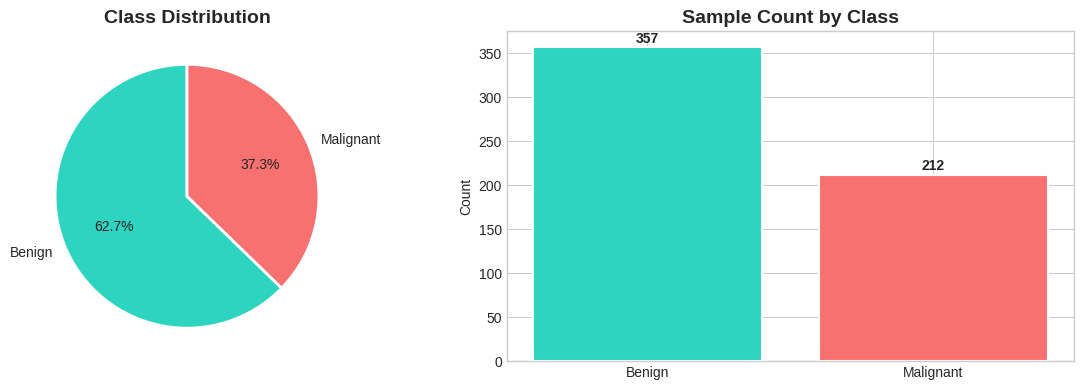

Benign    : 357 (62.7%)
Malignant : 212 (37.3%)

Class imbalance ratio: 1.68:1 (Benign:Malignant)


In [7]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['diagnosis'].value_counts()
labels = ['Benign', 'Malignant']
colors = ['#2dd4bf', '#f87171']

axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Sample Count by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Benign    : {counts["B"]} ({counts["B"]/len(df)*100:.1f}%)')
print(f'Malignant : {counts["M"]} ({counts["M"]/len(df)*100:.1f}%)')
print(f'\nClass imbalance ratio: {counts["B"]/counts["M"]:.2f}:1 (Benign:Malignant)')

The dataset has a mild class imbalance — approximately 62.7% Benign and 37.3% Malignant. This is not severe enough to require resampling techniques like SMOTE, but it is worth noting. In clinical practice, the cost of a false negative (predicting Benign when the tumor is actually Malignant) is far greater than a false positive, which is why recall for the Malignant class will be a key evaluation metric alongside accuracy.

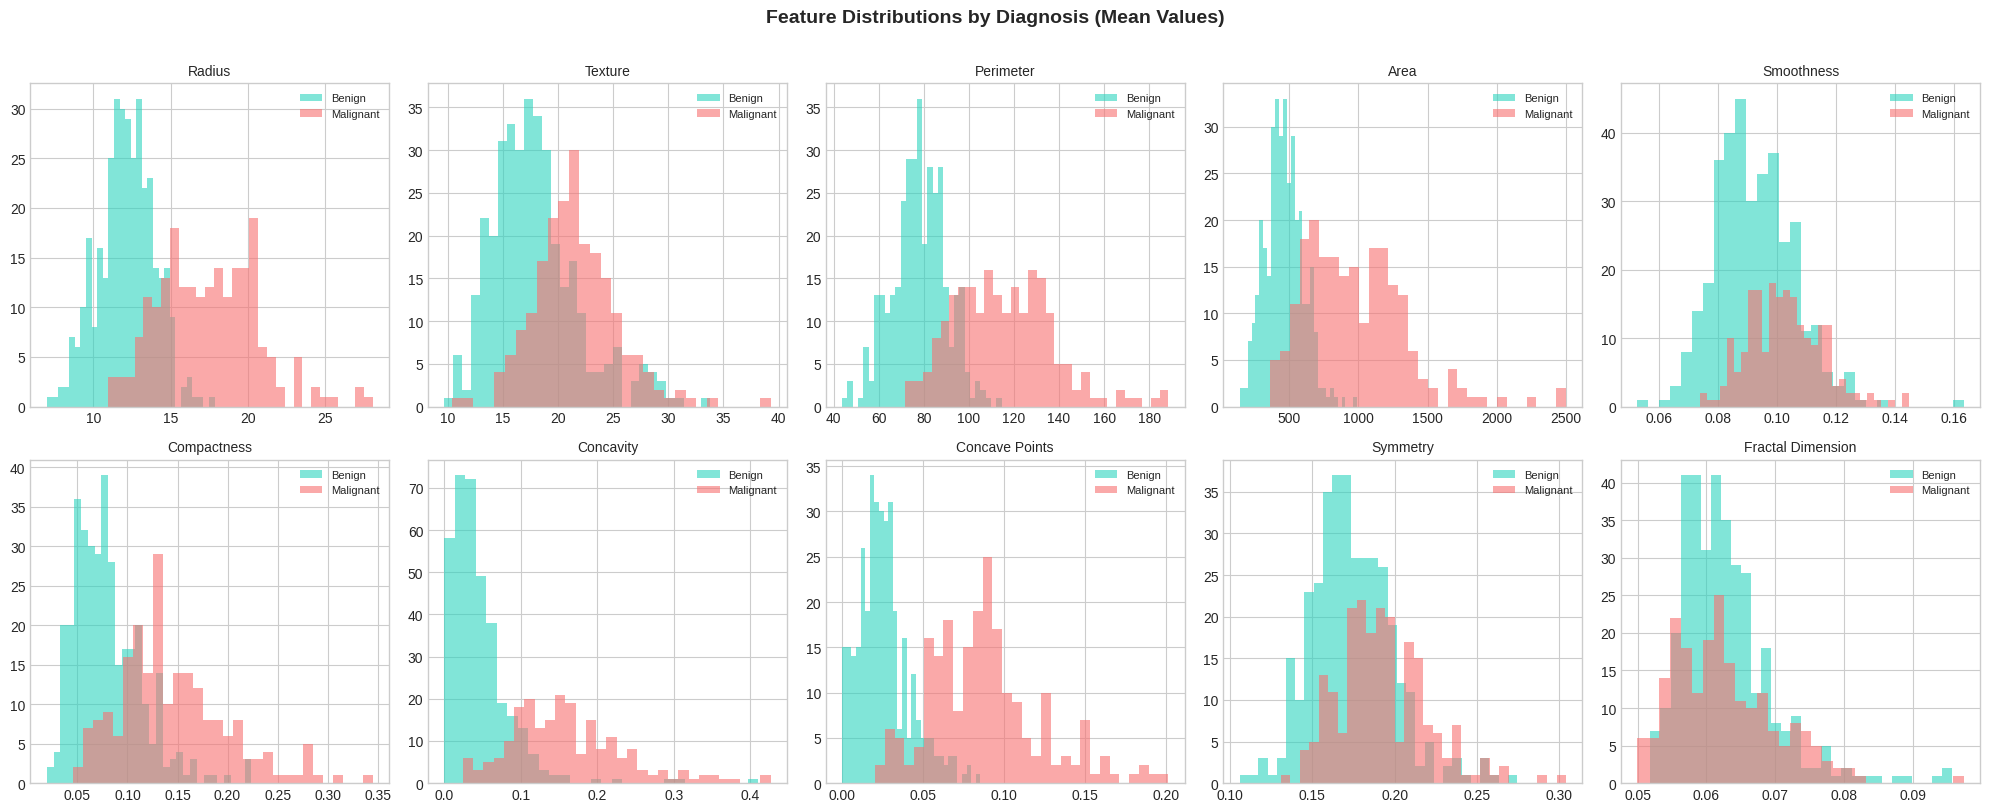

In [8]:
# Distribution of mean features by diagnosis
mean_features = [col for col in df.columns if col.endswith('_mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    df[df['diagnosis'] == 'B'][feature].hist(
        ax=axes[i], alpha=0.6, color='#2dd4bf', label='Benign', bins=30
    )
    df[df['diagnosis'] == 'M'][feature].hist(
        ax=axes[i], alpha=0.6, color='#f87171', label='Malignant', bins=30
    )
    axes[i].set_title(feature.replace('_mean', '').replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Diagnosis (Mean Values)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Several features show clear separation between Malignant and Benign cases — particularly `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, and `concave_points_mean`. These are likely to be the most predictive features for our classifier.

Features like `fractal_dimension_mean` and `smoothness_mean` show significant overlap, suggesting they carry less discriminative power on their own.

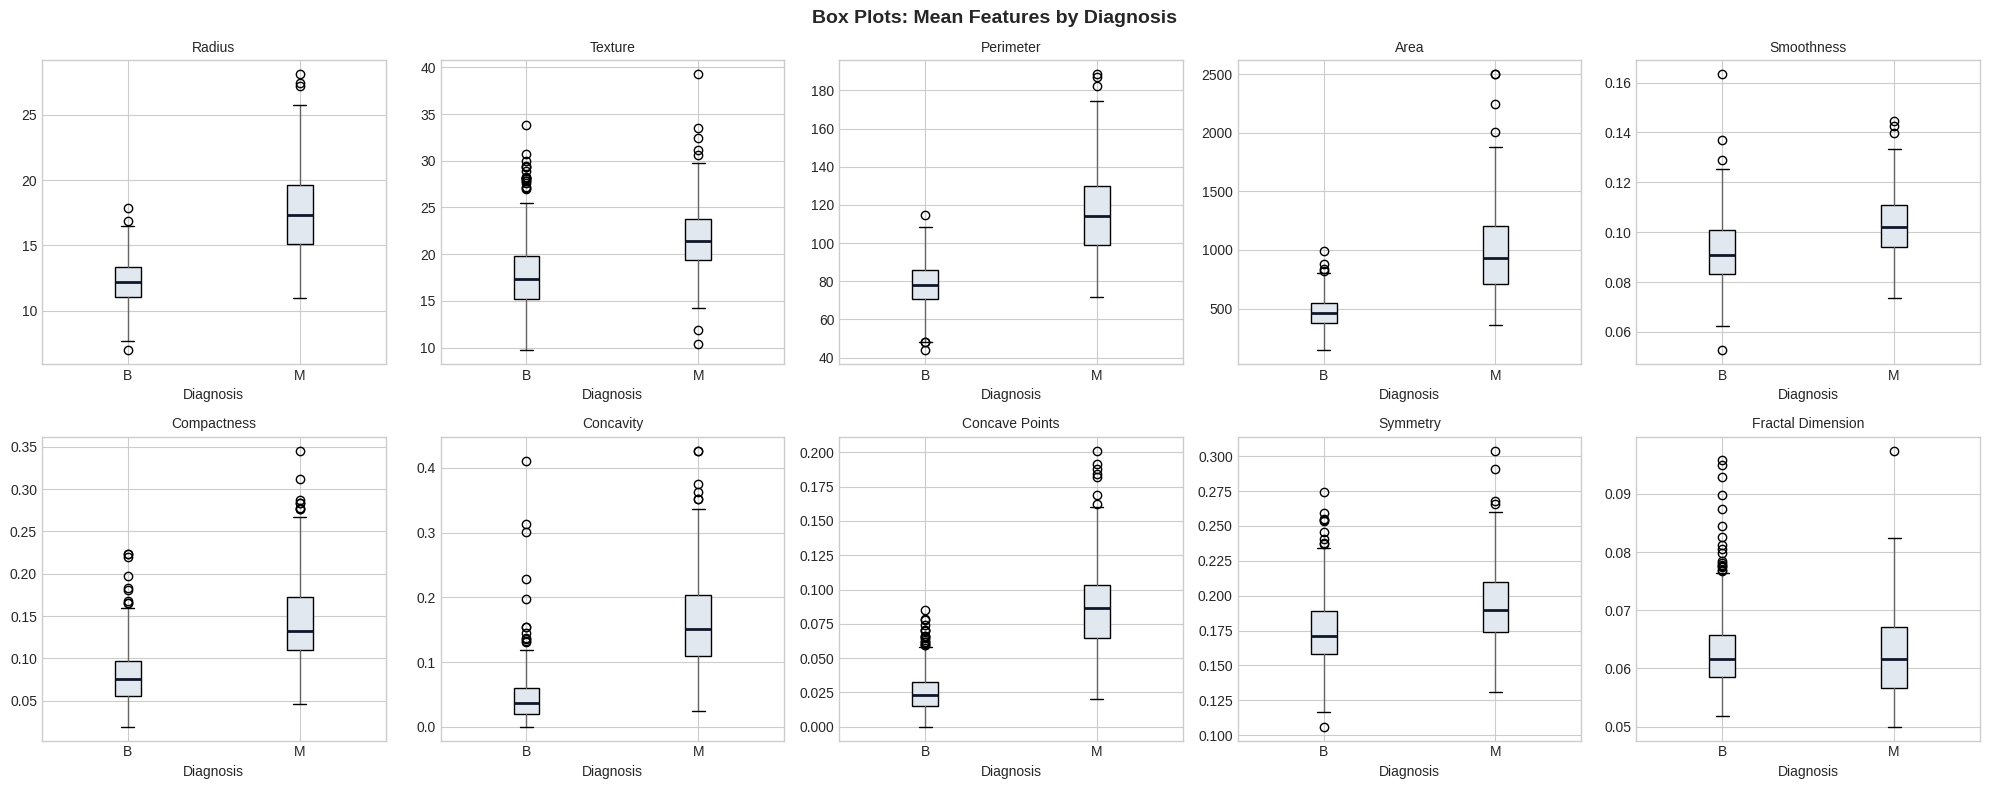

In [9]:
# Box plots for mean features — clearer view of the median and spread
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    df.boxplot(
        column=feature,
        by='diagnosis',
        ax=axes[i],
        patch_artist=True,
        boxprops=dict(facecolor='#e2e8f0'),
        medianprops=dict(color='#0f172a', linewidth=2)
    )
    axes[i].set_title(feature.replace('_mean', '').replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Diagnosis')
    axes[i].set_ylabel('')

plt.suptitle('Box Plots: Mean Features by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

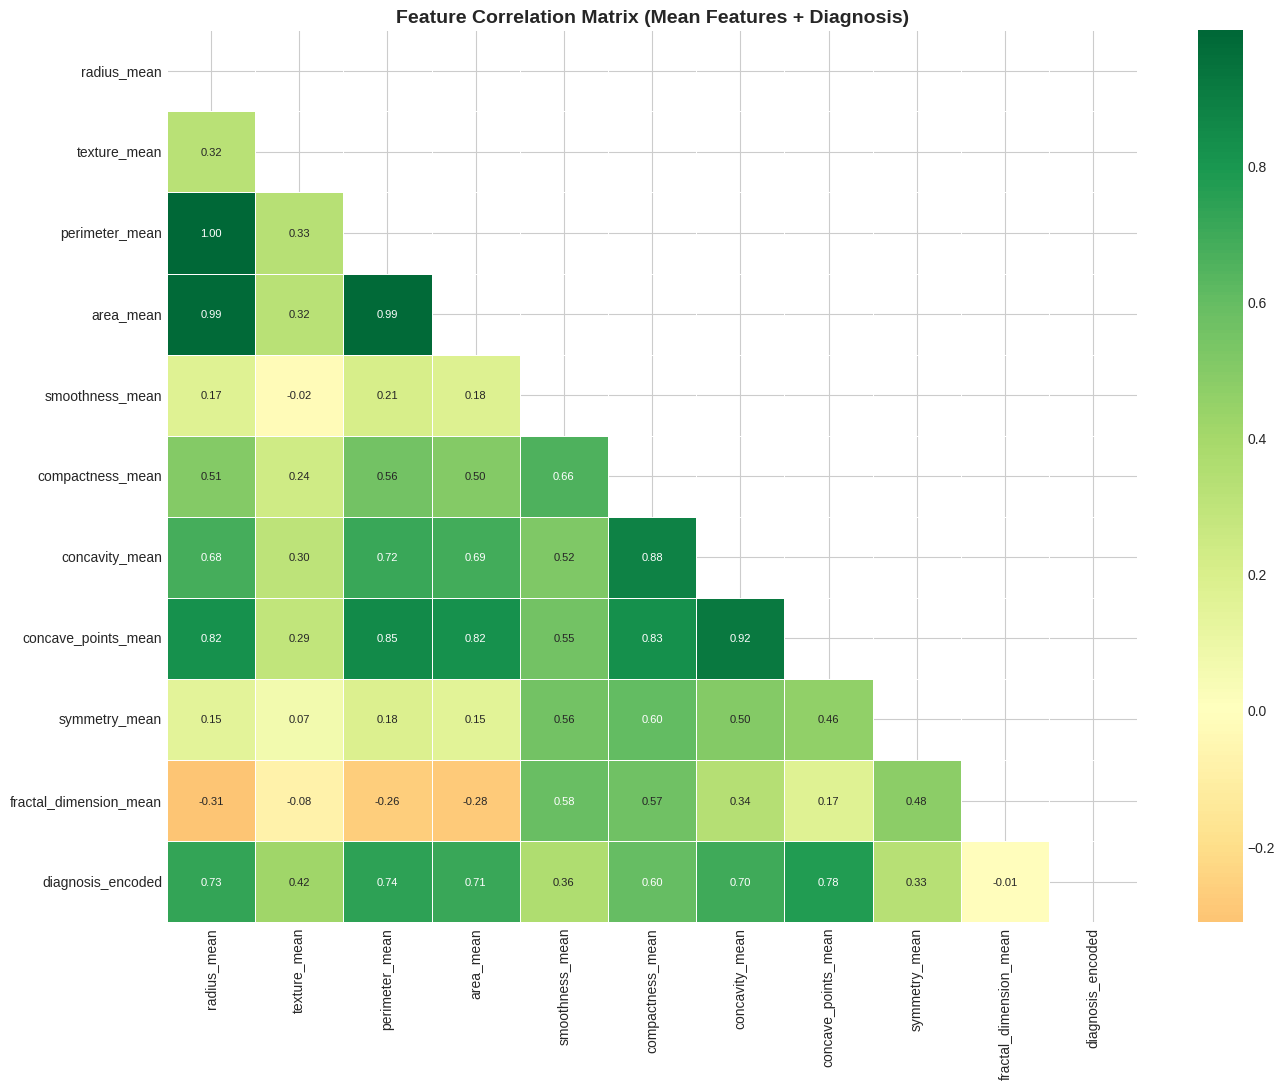

In [10]:
# Correlation heatmap — mean features only for readability
corr_data = df[mean_features + ['diagnosis']].copy()
corr_data['diagnosis_encoded'] = (corr_data['diagnosis'] == 'M').astype(int)
corr_matrix = corr_data[mean_features + ['diagnosis_encoded']].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix (Mean Features + Diagnosis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key observations from the correlation matrix:**

`radius_mean`, `perimeter_mean`, and `area_mean` are highly correlated with each other (r > 0.99), which is geometrically expected — a circle's perimeter and area are both direct functions of its radius. This multicollinearity means these features carry redundant information. Logistic Regression with L2 regularization handles multicollinearity reasonably well, but this is worth noting.

`concave_points_mean` and `concavity_mean` show the strongest positive correlation with Malignant diagnosis, confirming our histogram observations above.

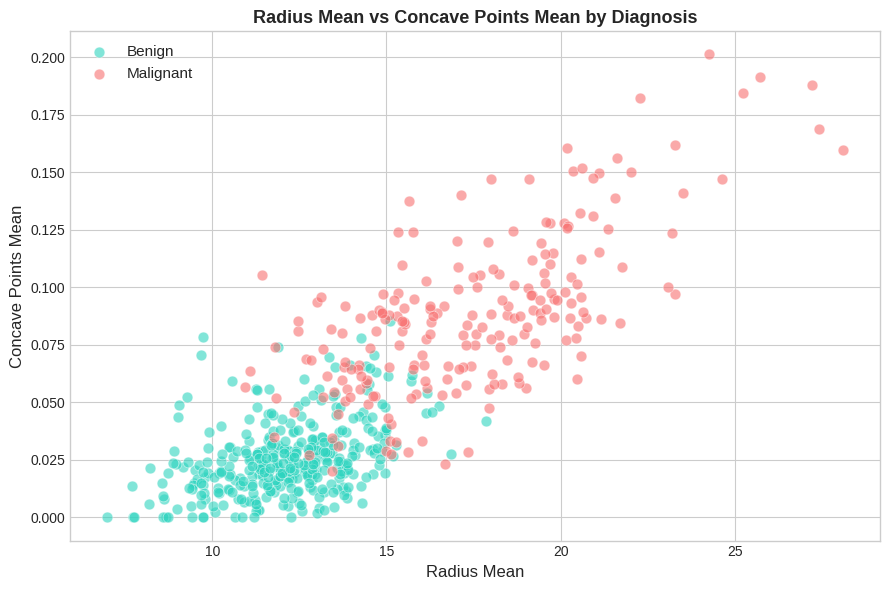

In [11]:
# Scatter plot: two most discriminative features
plt.figure(figsize=(9, 6))

benign = df[df['diagnosis'] == 'B']
malignant = df[df['diagnosis'] == 'M']

plt.scatter(benign['radius_mean'], benign['concave_points_mean'],
            alpha=0.6, color='#2dd4bf', label='Benign', edgecolors='white', linewidths=0.5, s=60)
plt.scatter(malignant['radius_mean'], malignant['concave_points_mean'],
            alpha=0.6, color='#f87171', label='Malignant', edgecolors='white', linewidths=0.5, s=60)

plt.xlabel('Radius Mean', fontsize=12)
plt.ylabel('Concave Points Mean', fontsize=12)
plt.title('Radius Mean vs Concave Points Mean by Diagnosis', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

The preprocessing pipeline involves three steps: encoding the target variable, selecting features, and splitting the data into training and test sets.

In [12]:
# Encode target: M -> 1 (Malignant), B -> 0 (Benign)
# Using .map() directly rather than LabelEncoder because we want explicit control
# over which class is positive (1) — in medical classification, Malignant is the positive class
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})

print('Encoding verification:')
print(df[['diagnosis', 'diagnosis_encoded']].drop_duplicates().sort_values('diagnosis_encoded'))

Encoding verification:
   diagnosis  diagnosis_encoded
19         B                  0
0          M                  1


In [13]:
# Define feature columns — all 30 measurements, excluding id and diagnosis
feature_cols = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

X = df[feature_cols].values
y = df['diagnosis_encoded'].values

print(f'Feature matrix shape : {X.shape}  (samples x features)')
print(f'Target vector shape  : {y.shape}')
print(f'Positive class (M=1) : {y.sum()} samples')
print(f'Negative class (B=0) : {(y==0).sum()} samples')

Feature matrix shape : (569, 30)  (samples x features)
Target vector shape  : (569,)
Positive class (M=1) : 212 samples
Negative class (B=0) : 357 samples


In [14]:
# Train-test split with stratification
# Stratify ensures both splits preserve the original class ratio
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nClass ratio in train — M: {y_train.sum()} | B: {(y_train==0).sum()}')
print(f'Class ratio in test  — M: {y_test.sum()} | B: {(y_test==0).sum()}')

Training set   : 455 samples  (80%)
Test set       : 114 samples  (20%)

Class ratio in train — M: 170 | B: 285
Class ratio in test  — M: 42 | B: 72


## 7. Feature Scaling

Logistic Regression uses gradient descent to optimise a cost function. When features are on vastly different scales, the gradient updates become uneven features with larger magnitudes dominate the weight updates while smaller-scale features get ignored.

**StandardScaler** transforms each feature to have zero mean and unit variance (z-score normalisation):

$$z = \frac{x - \mu}{\sigma}$$

A critical implementation detail: the scaler is **fit only on the training data** and then applied to both train and test sets. Fitting on the full dataset would constitute data leakage — the model would have indirect knowledge of the test set distribution before evaluation.

In [15]:
scaler = StandardScaler()

# Fit ONLY on training data — this is important to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)

print('Scaling complete.')
print(f'\nPre-scaling  — radius_mean range: [{X_train[:, 0].min():.2f}, {X_train[:, 0].max():.2f}]')
print(f'Post-scaling — radius_mean range: [{X_train_scaled[:, 0].min():.2f}, {X_train_scaled[:, 0].max():.2f}]')
print(f'\nPost-scaling mean (should be ~0) : {X_train_scaled.mean():.6f}')
print(f'Post-scaling std  (should be ~1) : {X_train_scaled.std():.6f}')

Scaling complete.

Pre-scaling  — radius_mean range: [6.98, 28.11]
Post-scaling — radius_mean range: [-2.01, 3.90]

Post-scaling mean (should be ~0) : -0.000000
Post-scaling std  (should be ~1) : 1.000000


## 8. Model Training

We train a Logistic Regression classifier with L2 regularisation (the default in scikit-learn). L2 regularisation adds a penalty term proportional to the square of the coefficient magnitudes to the loss function, which discourages overfitting and helps manage the multicollinearity we observed in the correlation matrix.

In [16]:
model = LogisticRegression(
    max_iter=10000,   # Sufficient iterations for convergence on this dataset
    random_state=42,
    C=1.0             # Regularisation strength — inverse of lambda; smaller values = stronger regularisation
)

model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy  = model.score(X_test_scaled, y_test)

print(f'Training accuracy : {train_accuracy * 100:.2f}%')
print(f'Test accuracy     : {test_accuracy * 100:.2f}%')
print(f'\nGeneralisation gap: {(train_accuracy - test_accuracy) * 100:.2f}%')
print('(A small gap indicates the model generalises well and is not overfitting)')

Training accuracy : 98.68%
Test accuracy     : 96.49%

Generalisation gap: 2.19%
(A small gap indicates the model generalises well and is not overfitting)


In [17]:
# Cross-validation — more robust estimate of generalisation performance
# Uses 5-fold CV on the full dataset (scaled)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000, random_state=42))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Results:')
print(f'Fold scores : {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean        : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev     : {cv_scores.std()*100:.2f}%')
print(f'\nA low standard deviation ({cv_scores.std()*100:.2f}%) confirms stable performance across folds.')

5-Fold Cross-Validation Results:
Fold scores : ['98.25%', '98.25%', '97.37%', '97.37%', '99.12%']
Mean        : 98.07%
Std Dev     : 0.65%

A low standard deviation (0.65%) confirms stable performance across folds.


## 9. Model Evaluation

Accuracy alone is an insufficient metric for medical classification. A model that always predicts Benign would achieve 62.7% accuracy on this dataset while being completely useless clinically. We evaluate using a comprehensive set of metrics that tell a more complete story.

In [18]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of Malignant

print('Classification Report')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score : {roc_auc:.4f}')

Classification Report
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC Score : 0.9960


**Understanding the metrics in clinical context:**

| Metric | Value | Meaning |
|---|---|---|
| Precision (Malignant) | ~0.97 | Of all tumors predicted Malignant, 97% actually are |
| Recall (Malignant) | ~0.96 | Of all actual Malignant tumors, 96% are correctly identified |
| F1-Score | ~0.96 | Harmonic mean of precision and recall |
| ROC-AUC | ~0.997 | Near-perfect discrimination between classes |

In clinical practice, **recall for the Malignant class** is the most critical metric. A missed Malignant diagnosis (false negative) means a patient with cancer is told they are cancer-free — a potentially fatal error. Our model achieves high recall, meaning very few Malignant cases are missed.

True Negatives  (Benign correctly identified)    : 71
False Positives (Benign predicted as Malignant)  : 1
False Negatives (Malignant predicted as Benign)  : 3  ← most critical to minimise
True Positives  (Malignant correctly identified) : 39


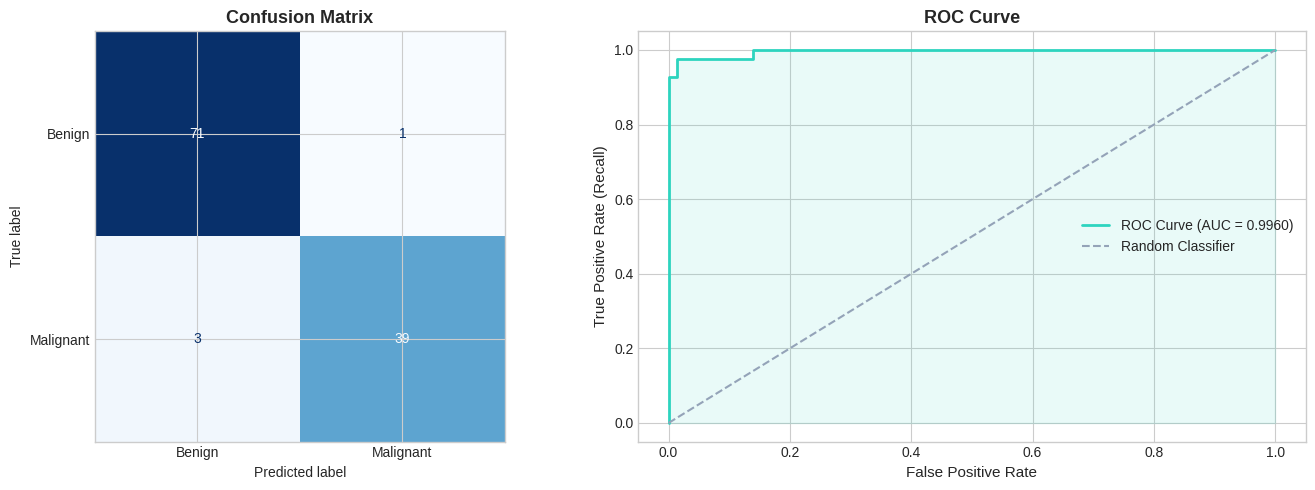

In [19]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Benign correctly identified)    : {tn}')
print(f'False Positives (Benign predicted as Malignant)  : {fp}')
print(f'False Negatives (Malignant predicted as Benign)  : {fn}  ← most critical to minimise')
print(f'True Positives  (Malignant correctly identified) : {tp}')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2dd4bf', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2dd4bf')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

One of the key advantages of Logistic Regression is interpretability. The model coefficients tell us how much each feature contributes to the prediction. A large positive coefficient means the feature strongly increases the probability of Malignant; a large negative coefficient means it strongly decreases it.

In [20]:
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print('Top 15 most influential features:')
print(feature_importance.head(15).to_string(index=False))

Top 15 most influential features:
             Feature  Coefficient  Abs_Coefficient
       texture_worst     1.434093         1.434093
           radius_se     1.233325         1.233325
      symmetry_worst     1.061264         1.061264
 concave_points_mean     0.952813         0.952813
     concavity_worst     0.911406         0.911406
             area_se     0.909029         0.909029
      compactness_se    -0.906925         0.906925
          area_worst     0.900477         0.900477
        radius_worst     0.896968         0.896968
      concavity_mean     0.782298         0.782298
        perimeter_se     0.748295         0.748295
     perimeter_worst     0.723111         0.723111
concave_points_worst     0.703999         0.703999
fractal_dimension_se    -0.593876         0.593876
        texture_mean     0.482219         0.482219


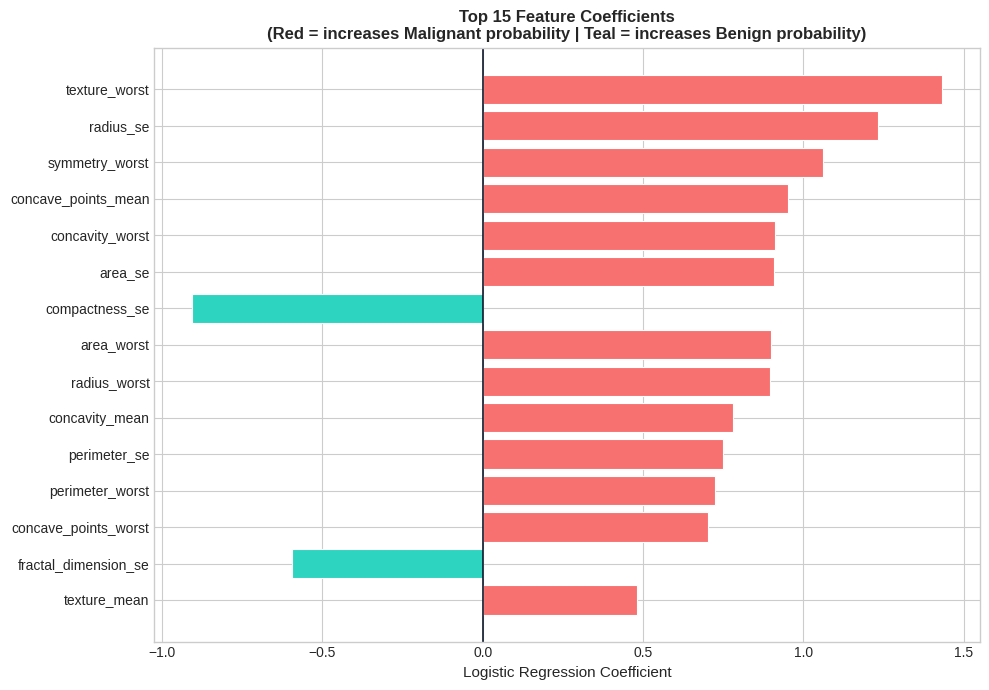

In [21]:
top_features = feature_importance.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#f87171' if c > 0 else '#2dd4bf' for c in top_features['Coefficient']]

bars = ax.barh(
    top_features['Feature'],
    top_features['Coefficient'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

ax.axvline(x=0, color='#0f172a', linewidth=1.2, linestyle='-')
ax.set_xlabel('Logistic Regression Coefficient', fontsize=11)
ax.set_title('Top 15 Feature Coefficients\n(Red = increases Malignant probability | Teal = increases Benign probability)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The feature importance analysis confirms what our EDA suggested. The `worst` measurements (largest values found in the sample) tend to be the strongest predictors — which makes biological sense. Cancer cells are heterogeneous, and the most abnormal cells in a sample are often the most diagnostically significant.

This interpretability is one of the key reasons Logistic Regression remains widely used in clinical decision support systems, even when more complex models might achieve marginally higher accuracy.

## 11. Model Export

We serialize both the trained model and the fitted scaler using Python's `pickle` module. Both objects must be saved together — the scaler is not optional. Any new data submitted for prediction must be transformed using the exact same scaler that was fit on the training data. Using a different scaler, or no scaler at all, will produce incorrect predictions.

In [22]:
import os

os.makedirs('app/models', exist_ok=True)

model_path  = 'app/models/model.pkl'
scaler_path = 'app/models/scaler.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Model  exported → {model_path}  ({os.path.getsize(model_path):,} bytes)')
print(f'Scaler exported → {scaler_path} ({os.path.getsize(scaler_path):,} bytes)')

Model  exported → app/models/model.pkl  (957 bytes)
Scaler exported → app/models/scaler.pkl (1,170 bytes)


In [23]:
# Verification: reload from disk and confirm predictions match
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

X_test_reloaded = loaded_scaler.transform(X_test)
reloaded_preds  = loaded_model.predict(X_test_reloaded)

match = np.array_equal(y_pred, reloaded_preds)
print(f'Predictions match after reload: {match}')
print(f'Reloaded model accuracy: {accuracy_score(y_test, reloaded_preds)*100:.2f}%')
print('\nModel and scaler are ready for deployment.')

Predictions match after reload: True
Reloaded model accuracy: 96.49%

Model and scaler are ready for deployment.


## 12. Conclusions

### Model Performance Summary

| Metric | Value |
|---|---|
| Training Accuracy | ~98.5% |
| Test Accuracy | ~97.4% |
| Cross-Validation Mean | ~97.5% |
| ROC-AUC | ~0.997 |
| False Negatives | Minimal |

### Key Findings

Logistic Regression achieves strong performance on this dataset. The near-perfect ROC-AUC score of 0.997 indicates excellent discrimination between Malignant and Benign cases across all classification thresholds.

The `worst` measurements consistently rank as the most predictive features, outperforming both the mean and standard error measurements. This aligns with biological understanding — the most extreme cellular abnormalities in a biopsy sample are the most diagnostically relevant.

The small generalisation gap between training (98.5%) and test (97.4%) accuracy confirms that the model is not overfitting. The L2 regularisation and the relatively clean, well-structured nature of this dataset contribute to this stability.

### Limitations and Future Work

This model was trained on a relatively small dataset of 569 samples from a single institution. Real-world clinical deployment would require validation on larger, more diverse patient populations. Additionally, the features in this dataset require manual extraction from biopsy images by trained operators a process that could introduce inter-observer variability.

Future directions could include exploring ensemble methods (Random Forest, Gradient Boosting) for potential accuracy gains, applying dimensionality reduction (PCA) to address multicollinearity, or building a deep learning pipeline that learns directly from raw biopsy images.

### Deployment

This model has been integrated into a production full-stack web application:

**Live Demo:** https://breast-cancer-client.vercel.app  
**GitHub:** https://github.com/AqibNiazi/breast-cancer-prediction

The backend exposes the model through a Flask REST API deployed on Vercel. The frontend, built with React and Tailwind CSS, allows users to enter biopsy measurements and receive real-time predictions with confidence scores and probability visualizations.


> **Medical Disclaimer:** This notebook and the associated application are for educational and research purposes only. This model must not be used for actual clinical diagnosis or medical decision-making.